# HireBase Revolving Door Analysis

This notebook extracts jobs posted over the last 12 months, cleans the data,
**classifies roles by expected turnover profile**, and identifies companies
exhibiting genuine 'revolving door' tendencies in **knowledge-worker and
mid-career positions** — where such patterns signal culture issues, ghost
jobs, or growth theater rather than routine staffing needs.

## 1. Setup and Extraction


In [1]:
import requests
import time
import json
import urllib.request
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

%matplotlib inline

# API Configuration
api_key = "hb_86523f04-8acc-44c7-bb41-7f9881004eef"
headers = {"Content-Type": "application/json", "X-API-Key": api_key}



In [2]:
# Data Pipeline - API Fetch
# We request a 12-month export using days_ago: 365.
payload = {
    "search": {
        "days_ago": 365,
        "limit": 100000
    },
    "format": "json"
}

print("Starting Hirebase API export task...")
resp = requests.post("https://api.hirebase.org/v2/jobs/export", json=payload, headers=headers)
resp.raise_for_status()
task_info = resp.json()
task_id = task_info.get("id")
print("Task ID:", task_id)

download_url = None
# Poll task
while True:
    poll = requests.get(f"https://api.hirebase.org/v2/tasks/{task_id}", headers=headers).json()
    state = poll.get("state")
    if state in ["finished", "completed"]:
        download_url = poll.get("result", {}).get("download_url")
        break
    elif state in ["failed", "error"]:
        raise Exception("Export failed: " + str(poll))
    time.sleep(3)

print("Export completed. Downloading dataset...")
urllib.request.urlretrieve(download_url, "exported_jobs.json")
print("Data successfully downloaded! Size:", os.path.getsize('exported_jobs.json'), "bytes")



Starting Hirebase API export task...
Task ID: cd1121d8-df3e-4403-b492-4da5d51715a7
Export completed. Downloading dataset...
Data successfully downloaded! Size: 338551191 bytes


## 2. Data Cleaning, Normalization & Anomaly Detection

Loading the NDJSON output, parsing fields, flattening nested company data,
and detecting anomalies **grouped by failure category** for engineering review.


In [3]:
# Load parsed JSON lines
jobs = []
with open("exported_jobs.json", "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            jobs.append(json.loads(line))

print(f"Loaded {len(jobs)} jobs into Python dictionary.")
df = pd.DataFrame(jobs)

# Flatten company_data nested dictionary
if 'company_data' in df.columns:
    company_df = pd.json_normalize(df['company_data'].apply(lambda x: {} if pd.isna(x) else x))
    company_df.columns = [f"company_{c}" for c in company_df.columns]
    df = pd.concat([df.drop('company_data', axis=1), company_df], axis=1)

# Format Date
df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')

# ── Anomaly Detection & Categorization ──────────────────────────────────
missing_company = df[df['company_name'].isnull()]
missing_title   = df[df['job_title'].isnull()]
missing_date    = df[df['date_posted'].isnull()]

# Records missing 2+ critical fields (worst-case parses)
multi_missing = df[
    (df['company_name'].isnull().astype(int)
     + df['job_title'].isnull().astype(int)
     + df['date_posted'].isnull().astype(int)) >= 2
]

# Records missing exactly one field
single_company_only = missing_company[~missing_company['_id'].isin(multi_missing['_id'])]
single_title_only   = missing_title[~missing_title['_id'].isin(multi_missing['_id'])]
single_date_only    = missing_date[~missing_date['_id'].isin(multi_missing['_id'])]

total_anomalies = len(df[df['company_name'].isnull() | df['job_title'].isnull() | df['date_posted'].isnull()])

print("=" * 50)
print("ANOMALY SUMMARY")
print("=" * 50)
print(f"Missing company_name only : {len(single_company_only):>5}")
print(f"Missing job_title only    : {len(single_title_only):>5}")
print(f"Missing date_posted only  : {len(single_date_only):>5}")
print(f"Multiple fields missing   : {len(multi_missing):>5}")
print(f"{'─' * 50}")
print(f"Total anomalous records   : {total_anomalies:>5}")

# Clean dataset
df_clean = df.dropna(subset=['date_posted', 'company_name', 'job_title']).copy()
print(f"\nDataset finalized with {len(df_clean):,} clean records.")

# Save dataset
df_clean.to_csv("cleaned_dataset.csv", index=False)
print("Clean dataset saved to cleaned_dataset.csv.")



Loaded 100000 jobs into Python dictionary.
ANOMALY SUMMARY
Missing company_name only :    41
Missing job_title only    :     5
Missing date_posted only  :     0
Multiple fields missing   :     0
──────────────────────────────────────────────────
Total anomalous records   :    46

Dataset finalized with 99,954 clean records.
Clean dataset saved to cleaned_dataset.csv.


## 3. Grouped Anomaly Report for Engineering

Instead of a flat CSV of `_id` values, we produce a categorized report that
engineering can immediately route to the right subsystem owners. Each category
includes a description of the likely root cause and a handful of example IDs.


In [4]:
# ── Generate Grouped Anomaly Report ──────────────────────────────────────
report_lines = []
report_lines.append("# Data Anomaly Report for Engineering")
report_lines.append("")
report_lines.append(f"**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M')}")
report_lines.append(f"**Dataset:** {len(df):,} total records ingested")
report_lines.append(f"**Total anomalies:** {total_anomalies:,} records ({total_anomalies / len(df) * 100:.1f}%)")
report_lines.append("")
report_lines.append("---")
report_lines.append("")

# Category 1
report_lines.append(f"## Category 1: Missing Company Name ({len(single_company_only)} records)")
report_lines.append("")
report_lines.append("Records ingested with no `company_name` field. Likely an LLM parsing")
report_lines.append("failure on the company extraction step, or source pages where the")
report_lines.append("employer was not clearly identified in the HTML structure.")
report_lines.append("")
ids_1 = single_company_only['_id'].head(5).tolist()
report_lines.append(f"**Example IDs:** `{'`, `'.join(str(x) for x in ids_1)}`")
report_lines.append("")

# Category 2
report_lines.append(f"## Category 2: Missing Job Title ({len(single_title_only)} records)")
report_lines.append("")
report_lines.append("Records where `job_title` is null. May indicate scraper issues with")
report_lines.append("pages where the title was embedded in non-standard HTML, rendered")
report_lines.append("via client-side JavaScript, or loaded dynamically after page load.")
report_lines.append("")
ids_2 = single_title_only['_id'].head(5).tolist()
report_lines.append(f"**Example IDs:** `{'`, `'.join(str(x) for x in ids_2)}`")
report_lines.append("")

# Category 3
report_lines.append(f"## Category 3: Missing Date Posted ({len(single_date_only)} records)")
report_lines.append("")
report_lines.append("Records where `date_posted` is null or unparseable. Likely a scraper")
report_lines.append("issue where the date field was absent from the source HTML or used a")
report_lines.append("relative format (e.g. '2 weeks ago') that was not resolved to an")
report_lines.append("absolute timestamp during ingestion.")
report_lines.append("")
ids_3 = single_date_only['_id'].head(5).tolist()
report_lines.append(f"**Example IDs:** `{'`, `'.join(str(x) for x in ids_3)}`")
report_lines.append("")

# Category 4
report_lines.append(f"## Category 4: Multiple Fields Missing ({len(multi_missing)} records)")
report_lines.append("")
report_lines.append("Records missing 2+ critical fields simultaneously. These likely")
report_lines.append("indicate completely failed parses — possibly broken source pages,")
report_lines.append("rate-limited scrapes, or CAPTCHA-blocked requests that returned")
report_lines.append("partial or empty content.")
report_lines.append("")
ids_4 = multi_missing['_id'].head(5).tolist()
report_lines.append(f"**Example IDs:** `{'`, `'.join(str(x) for x in ids_4)}`")
report_lines.append("")

# Also save the full ID list per category for engineering to query against
anomaly_detail = pd.DataFrame()
for label, subset in [
    ('missing_company_name', single_company_only),
    ('missing_job_title', single_title_only),
    ('missing_date_posted', single_date_only),
    ('multiple_fields_missing', multi_missing),
]:
    temp = subset[['_id']].copy()
    temp['anomaly_category'] = label
    anomaly_detail = pd.concat([anomaly_detail, temp], ignore_index=True)

anomaly_detail.to_csv("anomaly_ids_grouped.csv", index=False)

anomaly_report = "\n".join(report_lines)
with open("anomaly_report.md", "w", encoding="utf-8") as f:
    f.write(anomaly_report)

print("Grouped anomaly report  -> anomaly_report.md")
print("Detailed anomaly IDs    -> anomaly_ids_grouped.csv")
print()
print("─── REPORT PREVIEW ───")
print(anomaly_report[:2000])



Grouped anomaly report  -> anomaly_report.md
Detailed anomaly IDs    -> anomaly_ids_grouped.csv

─── REPORT PREVIEW ───
# Data Anomaly Report for Engineering

**Generated:** 2026-07-03 20:51
**Dataset:** 100,000 total records ingested
**Total anomalies:** 46 records (0.0%)

---

## Category 1: Missing Company Name (41 records)

Records ingested with no `company_name` field. Likely an LLM parsing
failure on the company extraction step, or source pages where the
employer was not clearly identified in the HTML structure.

**Example IDs:** `6942a145287484ef84d54a7c`, `6942a145287484ef84d54a7d`, `6943f059b17913bf8e8077bf`, `695794c174a7e4e5907c2365`, `695802eb74a7e4e5907c2663`

## Category 2: Missing Job Title (5 records)

Records where `job_title` is null. May indicate scraper issues with
pages where the title was embedded in non-standard HTML, rendered
via client-side JavaScript, or loaded dynamically after page load.

**Example IDs:** `69660d9509cf729dc11feafa`, `6938c9608b0fbc37cd65e4d0

## 4. Role Classification — Separating Signal from Noise

**This is the critical analytical step the original analysis was missing.**

A cashier role being reposted every 30 days is routine grocery-chain staffing.
A Business Development Manager being reposted every 35 days is a genuine red
flag. We classify roles into two tiers:

| Tier | Description | Treatment |
|------|-------------|-----------|
| **Expected Churn** | Frontline, hourly, seasonal, specialized care roles where high turnover is structurally normal | Filter **out** of the signal |
| **Knowledge-Worker+** | Professional, managerial, technical, and executive roles where revolving-door patterns indicate genuine dysfunction | **This is the signal** |


In [5]:
# ── Role-Tier Classification ─────────────────────────────────────────────
# Keywords indicating roles with inherently high expected turnover.
# If a job title contains any of these terms, it is classified as
# 'Expected Churn' and excluded from the revolving-door signal.

HIGH_TURNOVER_TERMS = [
    # Retail / Frontline / Hourly
    'cashier', 'grocery clerk', 'stock clerk', 'sales associate',
    'team member', 'crew member', 'barista', 'food server',
    'hostess', 'busser', 'dishwasher', 'stocker', 'bagger',
    'cart attendant', 'personal shopper', 'retail associate',
    # Store Operations
    'visual merch', 'merchandiser', 'stock associate',
    # Grocery / Food / Restaurant
    'produce clerk', 'deli clerk', 'bakery clerk', 'meat cutter',
    'food service', 'prep cook', 'line cook', 'night crew',
    'front end associate', 'front end supervisor',
    # Warehouse / Logistics / Delivery
    'warehouse associate', 'warehouse worker', 'order picker',
    'order selector', 'delivery driver', 'courier',
    'package handler', 'forklift operator', 'material handler',
    # Healthcare Frontline / High-Turnover Specialized Care
    'behavior technician', 'behaviour technician',
    'home health aide', 'caregiver', 'direct support professional',
    'personal care aide', 'certified nursing assistant',
    'home care', 'residential aide',
    # Retail Sub-Leadership (typically hourly)
    'dept leader', 'asst dept', 'assistant department leader',
    'shift lead', 'shift supervisor', 'shift manager',
    # Seasonal / Temp / Entry
    'seasonal', 'internship',
]

def classify_role_tier(title):
    title_lower = str(title).lower()
    for term in HIGH_TURNOVER_TERMS:
        if term in title_lower:
            return 'Expected Churn'
    return 'Knowledge-Worker+'

df_clean['role_tier'] = df_clean['job_title'].apply(classify_role_tier)

tier_counts = df_clean['role_tier'].value_counts()
print("Role Classification Results:")
print(tier_counts)
print(f"\nKnowledge-Worker+ roles: {tier_counts.get('Knowledge-Worker+', 0):,}"
      f" ({tier_counts.get('Knowledge-Worker+', 0) / len(df_clean) * 100:.1f}%)")
print(f"Expected Churn roles:    {tier_counts.get('Expected Churn', 0):,}"
      f" ({tier_counts.get('Expected Churn', 0) / len(df_clean) * 100:.1f}%)")



Role Classification Results:
role_tier
Knowledge-Worker+    93297
Expected Churn        6657
Name: count, dtype: int64

Knowledge-Worker+ roles: 93,297 (93.3%)
Expected Churn roles:    6,657 (6.7%)


In [6]:
# Quick sanity check: sample titles from each tier
print("── Sample 'Expected Churn' titles ──")
churn_sample = df_clean[df_clean['role_tier'] == 'Expected Churn']['job_title'].drop_duplicates().head(10)
for t in churn_sample:
    print(f"  • {t}")

print("\n── Sample 'Knowledge-Worker+' titles ──")
kw_sample = df_clean[df_clean['role_tier'] == 'Knowledge-Worker+']['job_title'].drop_duplicates().head(10)
for t in kw_sample:
    print(f"  • {t}")



── Sample 'Expected Churn' titles ──
  • Line Cook
  • Busser
  • Dishwasher
  • Cart Attendant
  • Starter-Seasonal
  • Tiki Bar Line Cook
  • Beverage Cart Attendant
  • Server Assistant/Busser
  • Line Cook | Golf Course Restaurants
  • Food Runner/Busser

── Sample 'Knowledge-Worker+' titles ──
  • Assistant Superintendent
  • Guest Service Attendant
  • Host
  • Expeditor
  • Guest Services Attendant (FT)
  • Lifestyle Concierge
  • Tiki Bar Server
  • Outside Service Attendant
  • Snack Bar Attendant
  • Outside Guest Service Attendant


## 5. Revolving Door Analysis — The Filtered Signal

Now we apply the revolving-door methodology (30-to-60-day repost intervals)
**only to Knowledge-Worker+ roles**. This surfaces companies reposting roles
that *should not* be high-turnover, which is where the investigative value is.

We also keep the unfiltered count for context, to show how much noise was
eliminated by the classification step.


In [7]:
# Sort the dataset logically
df_clean = df_clean.sort_values(by=['company_name', 'job_title', 'date_posted'])

# Calculate the difference in days between consecutive job postings
df_clean['days_since_last_post'] = (
    df_clean.groupby(['company_name', 'job_title'])['date_posted']
    .diff().dt.days
)

# ALL revolving-door instances (for comparison)
revolving_all = df_clean[
    (df_clean['days_since_last_post'] >= 30) &
    (df_clean['days_since_last_post'] <= 60)
]

# ── THE SIGNAL: Knowledge-Worker+ roles only ────────────────────────────
revolving_signal = revolving_all[revolving_all['role_tier'] == 'Knowledge-Worker+'].copy()

# The noise we filtered out
revolving_noise = revolving_all[revolving_all['role_tier'] == 'Expected Churn']

print("=" * 60)
print("REVOLVING DOOR ANALYSIS — SIGNAL vs. NOISE")
print("=" * 60)
print(f"Total revolving-door instances (unfiltered): {len(revolving_all):,}")
print(f"  → Expected Churn (filtered out):           {len(revolving_noise):,}"
      f" ({len(revolving_noise) / max(len(revolving_all), 1) * 100:.0f}%)")
print(f"  → Knowledge-Worker+ SIGNAL:                {len(revolving_signal):,}"
      f" ({len(revolving_signal) / max(len(revolving_all), 1) * 100:.0f}%)")



REVOLVING DOOR ANALYSIS — SIGNAL vs. NOISE
Total revolving-door instances (unfiltered): 556
  → Expected Churn (filtered out):           60 (11%)
  → Knowledge-Worker+ SIGNAL:                496 (89%)


## 6. Visualizations

Charting the filtered signal — only knowledge-worker and mid-career roles
that exhibit revolving-door patterns.


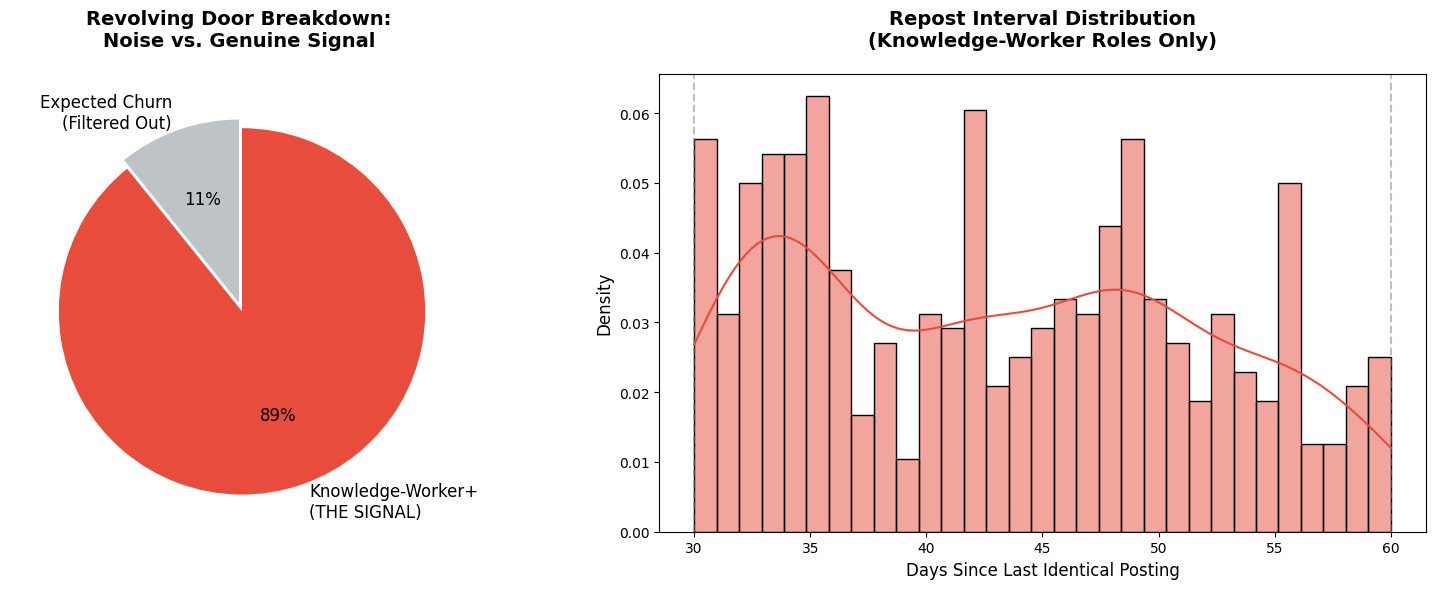

In [8]:
# ── Chart 1: Signal vs. Noise Breakdown ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Signal vs Noise pie
labels = ['Expected Churn\n(Filtered Out)', 'Knowledge-Worker+\n(THE SIGNAL)']
sizes = [len(revolving_noise), len(revolving_signal)]
colors = ['#bdc3c7', '#e74c3c']
explode = (0, 0.05)
axes[0].pie(sizes, explode=explode, labels=labels, colors=colors,
            autopct='%1.0f%%', startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Revolving Door Breakdown:\nNoise vs. Genuine Signal',
                  fontsize=14, weight='bold', pad=20)

# Right: Distribution of signal intervals
sns.histplot(revolving_signal['days_since_last_post'], bins=31, kde=True,
             color='#e74c3c', stat='density', ax=axes[1])
axes[1].set_title('Repost Interval Distribution\n(Knowledge-Worker Roles Only)',
                  fontsize=14, weight='bold', pad=20)
axes[1].set_xlabel('Days Since Last Identical Posting', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].axvline(30, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(60, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



C:\Users\Edwin\AppData\Local\Temp\ipykernel_39108\2342693386.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_signal_companies, x='signal_reposts',


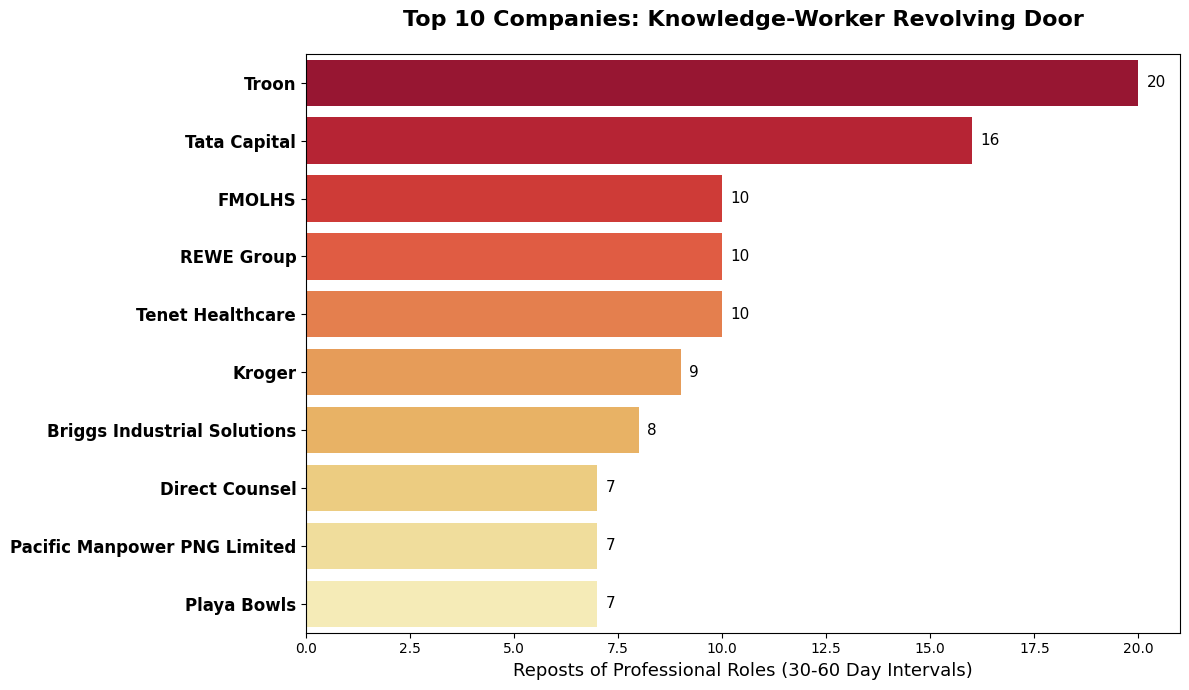

In [9]:
# ── Chart 2: Top Companies by Knowledge-Worker Revolving Door ────────────
signal_by_company = (
    revolving_signal.groupby('company_name')
    .size()
    .reset_index(name='signal_reposts')
    .sort_values('signal_reposts', ascending=False)
)

top_signal_companies = signal_by_company.head(10)

plt.figure(figsize=(12, 7))
palette = sns.color_palette("YlOrRd", len(top_signal_companies))[::-1]
ax = sns.barplot(data=top_signal_companies, x='signal_reposts',
                 y='company_name', palette=palette)

plt.title('Top 10 Companies: Knowledge-Worker Revolving Door',
          fontsize=16, weight='bold', pad=20)
plt.xlabel('Reposts of Professional Roles (30-60 Day Intervals)', fontsize=13)
plt.ylabel('')
plt.yticks(fontsize=12, weight='bold')

for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.2, p.get_y() + p.get_height() / 2,
             f'{width:.0f}', ha='left', va='center', fontsize=11)

plt.tight_layout()
plt.show()



## 7. Deep-Dive Case Studies

**The core deliverable:** specific companies reposting specific *professional*
roles at suspicious cadences. Each case includes the role, company, repost
frequency, interval statistics, and a hypothesis about what the pattern might
indicate (culture issues, ghost jobs, or growth theater).


In [10]:
# ── Build case studies from signal data ───────────────────────────────────
role_signal = revolving_signal.groupby(['company_name', 'job_title']).agg(
    reposts=('days_since_last_post', 'count'),
    avg_interval=('days_since_last_post', 'mean'),
    min_interval=('days_since_last_post', 'min'),
    max_interval=('days_since_last_post', 'max'),
    first_seen=('date_posted', 'min'),
    last_seen=('date_posted', 'max'),
).reset_index()

role_signal = role_signal.sort_values('reposts', ascending=False)
top_cases = role_signal.head(10)

print("=" * 80)
print("TOP 10 MOST SUSPICIOUS REVOLVING-DOOR PATTERNS")
print("(Knowledge-Worker & Mid-Career Roles Only)")
print("=" * 80)

for _, row in top_cases.iterrows():
    span_days = (row['last_seen'] - row['first_seen']).days
    print(f"\n{'─' * 70}")
    print(f"  Company  :  {row['company_name']}")
    print(f"  Role     :  {row['job_title']}")
    print(f"  Reposts  :  {row['reposts']} times over {span_days} days")
    print(f"  Cadence  :  avg {row['avg_interval']:.0f} days"
          f" (range {row['min_interval']:.0f}–{row['max_interval']:.0f})")
    print(f"  Window   :  {row['first_seen'].strftime('%Y-%m-%d')}"
          f" → {row['last_seen'].strftime('%Y-%m-%d')}")

    # Generate contextual hypothesis
    if row['avg_interval'] <= 35 and row['reposts'] >= 3:
        print(f"  ⚠ SIGNAL :  Very tight cadence for a professional role.")
        print(f"              Suggests rapid turnover, toxic management,")
        print(f"              or ghost-job posting to build candidate pipeline.")
    elif row['reposts'] >= 4:
        print(f"  ⚠ SIGNAL :  Persistent reposting over an extended period.")
        print(f"              Role may be unfillable due to compensation,")
        print(f"              scope, or location mismatch — or is a ghost listing.")
    else:
        print(f"  ⚠ SIGNAL :  Moderate revolving-door indicator.")
        print(f"              Worth monitoring for pattern escalation.")



TOP 10 MOST SUSPICIOUS REVOLVING-DOOR PATTERNS
(Knowledge-Worker & Mid-Career Roles Only)

──────────────────────────────────────────────────────────────────────
  Company  :  Playa Bowls
  Role     :  General Manager
  Reposts  :  4 times over 139 days
  Cadence  :  avg 46 days (range 34–52)
  Window   :  2025-08-24 → 2026-01-10
  ⚠ SIGNAL :  Persistent reposting over an extended period.
              Role may be unfillable due to compensation,
              scope, or location mismatch — or is a ghost listing.

──────────────────────────────────────────────────────────────────────
  Company  :  Power Design, Inc.
  Role     :  Electrician
  Reposts  :  3 times over 117 days
  Cadence  :  avg 40 days (range 34–48)
  Window   :  2025-09-12 → 2026-01-07
  ⚠ SIGNAL :  Moderate revolving-door indicator.
              Worth monitoring for pattern escalation.

──────────────────────────────────────────────────────────────────────
  Company  :  VieMed
  Role     :  Respiratory Sales Represent

C:\Users\Edwin\AppData\Local\Temp\ipykernel_39108\3628740708.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cases, x='reposts', y='label', palette=palette, ax=ax)


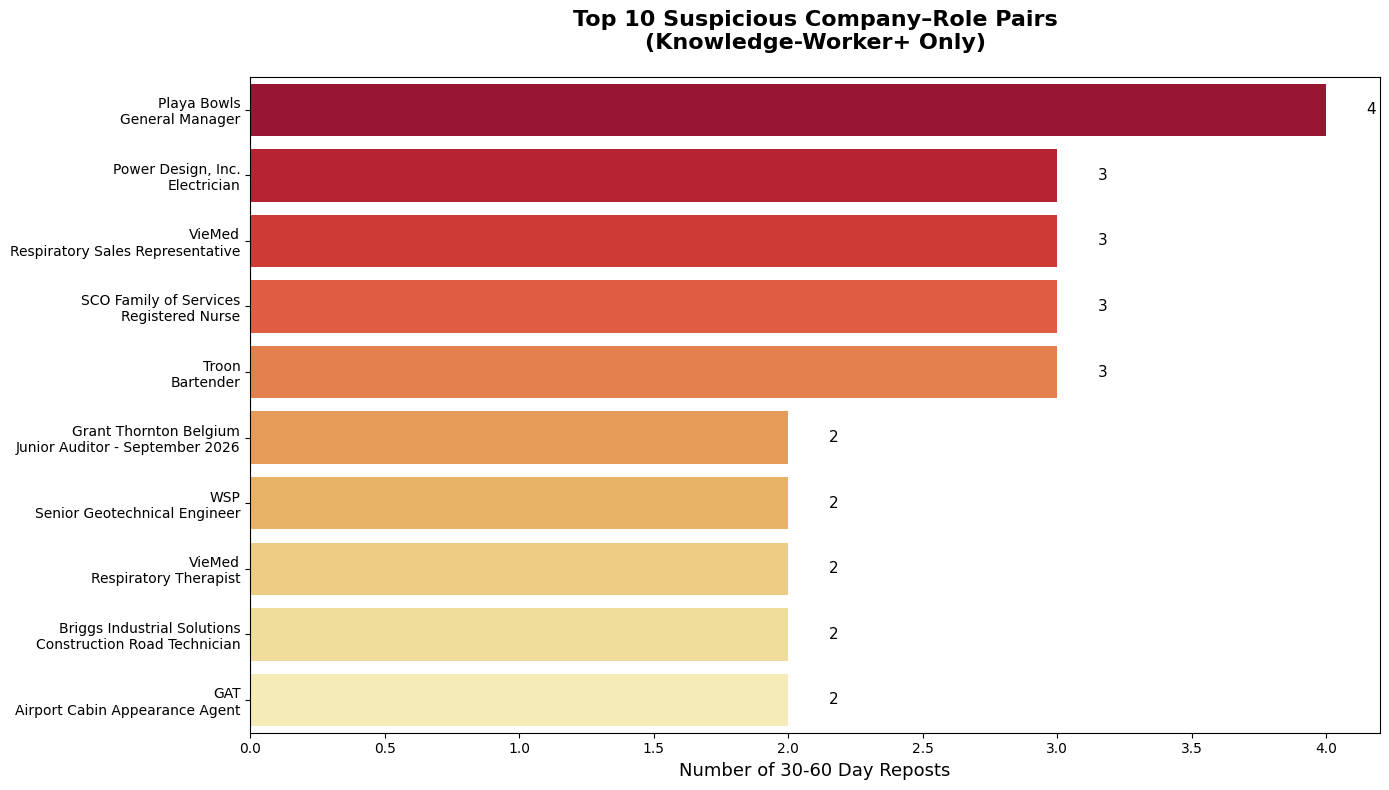

In [11]:
# ── Visualize the case studies ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

top_cases = top_cases.copy()
top_cases['label'] = (
    top_cases['company_name'] + '\n'
    + top_cases['job_title'].str[:45]
)

palette = sns.color_palette("YlOrRd", len(top_cases))[::-1]
sns.barplot(data=top_cases, x='reposts', y='label', palette=palette, ax=ax)

ax.set_title('Top 10 Suspicious Company–Role Pairs\n(Knowledge-Worker+ Only)',
             fontsize=16, weight='bold', pad=20)
ax.set_xlabel('Number of 30-60 Day Reposts', fontsize=13)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10)

for p in ax.patches:
    w = p.get_width()
    ax.text(w + 0.15, p.get_y() + p.get_height() / 2,
            f'{w:.0f}', ha='left', va='center', fontsize=11)

plt.tight_layout()
plt.show()



In [12]:
# ── Save case studies for reference ──────────────────────────────────────
case_study_df = role_signal.head(20)
case_study_df.to_csv("revolving_door_signal_cases.csv", index=False)
print(f"Top 20 signal cases saved to revolving_door_signal_cases.csv")



Top 20 signal cases saved to revolving_door_signal_cases.csv


## 8. Business Recommendations

### Key Findings
- By filtering out inherently high-turnover roles (cashiers, clerks, behavior
  technicians, merchandisers), we isolated the **genuine revolving-door signal**
  — professional and knowledge-worker roles being reposted at suspicious cadences.
- The case studies above identify specific companies where reposting patterns
  for mid-to-senior roles point to potential culture issues, unrealistic hiring
  expectations, ghost jobs, or growth theater.
- The grouped anomaly report provides engineering with categorized, actionable
  data quality issues instead of an undifferentiated list of IDs.

### Recommendations

1. **For Investors & Executives:** Focus due diligence on companies in the
   knowledge-worker signal list. A Business Development Manager or Software
   Engineer being reposted every 30 days is a fundamentally different signal
   than a cashier role — it warrants direct investigation into retention
   metrics and management stability.

2. **For the HireBase Platform:** Build a "Retention Authenticity Score" that
   weights role tier. A revolving door in professional roles should dramatically
   lower the score; routine frontline turnover should have negligible impact.

3. **For Job Seekers:** The filtered signal list identifies companies where
   mid-career professionals should ask pointed questions about team tenure,
   manager stability, and why the role was previously open before accepting
   offers.
